## Fintech Transaction Analysis: Insights into Regional, Channel, and User Behavior

### Executive Summary

##### This analysis explores transaction patterns within a fintech dataset, focusing on regional performance, payment channels, transaction types, device usage, fraud activity, and temporal trends. The goal is to uncover key drivers of transaction volume, user behavior, and potential risk areas to support data-driven decision-making.

##### The results show that Bank Transfer is the dominant transaction channel, leading in both usage and total transaction value. Ibadan and Abuja emerge as top-performing regions, driving the highest transaction volume and value. Additionally, Payment and Airtime services account for the majority of transactions, highlighting their importance to overall platform engagement.

##### User activity is highest on Web and Android platforms, while transaction trends vary over time, with peak activity observed on specific days. The platform also demonstrates a high transaction success rate, although some failed and pending transactions remain.Fraud analysis indicates a moderate level of risk, with Lagos recording the highest number of flagged transactions.

##### Overall, the findings highlight opportunities to strengthen high-performing areas, improve underutilized services, and enhance fraud monitoring to support balanced growth and operational efficiency.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Oluchi\Downloads\fintech_dataset.csv")

In [3]:
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,timestamp
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01 00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01 01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01 02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01 03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...
495,496,1017,365409.29,airtime,wallet,failed,Abuja,android,0,2025-01-21 15:00:00
496,497,1792,347011.94,transfer,bank_transfer,success,Lagos,web,0,2025-01-21 16:00:00
497,498,1734,83782.01,payment,card,success,Kano,web,1,2025-01-21 17:00:00
498,499,1565,439375.24,bill,wallet,success,Port Harcourt,ios,0,2025-01-21 18:00:00


In [4]:
pd.set_option("display.max.row", 500)
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,timestamp
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01 00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01 01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01 02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01 03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01 04:00:00
5,6,1071,127454.74,payment,ussd,pending,Kano,ios,0,2025-01-01 05:00:00
6,7,1700,147997.65,transfer,ussd,success,Ibadan,web,0,2025-01-01 06:00:00
7,8,1020,161614.11,transfer,card,success,Kano,android,0,2025-01-01 07:00:00
8,9,1614,424410.56,transfer,bank_transfer,success,Abuja,web,0,2025-01-01 08:00:00
9,10,1121,68742.36,transfer,bank_transfer,success,Ibadan,ios,0,2025-01-01 09:00:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      500 non-null    int64  
 1   user_id             500 non-null    int64  
 2   transaction_amount  500 non-null    float64
 3   transaction_type    500 non-null    object 
 4   payment_channel     500 non-null    object 
 5   transaction_status  500 non-null    object 
 6   region              500 non-null    object 
 7   device_type         500 non-null    object 
 8   fraud_flag          500 non-null    int64  
 9   timestamp           500 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 39.2+ KB


In [6]:
df= df.drop_duplicates()
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,timestamp
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01 00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01 01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01 02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01 03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01 04:00:00
5,6,1071,127454.74,payment,ussd,pending,Kano,ios,0,2025-01-01 05:00:00
6,7,1700,147997.65,transfer,ussd,success,Ibadan,web,0,2025-01-01 06:00:00
7,8,1020,161614.11,transfer,card,success,Kano,android,0,2025-01-01 07:00:00
8,9,1614,424410.56,transfer,bank_transfer,success,Abuja,web,0,2025-01-01 08:00:00
9,10,1121,68742.36,transfer,bank_transfer,success,Ibadan,ios,0,2025-01-01 09:00:00


In [7]:
df["transaction_type"]= df["transaction_type"].str.strip()
df["payment_channel"]= df["payment_channel"].str.strip()
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,timestamp
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01 00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01 01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01 02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01 03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01 04:00:00
5,6,1071,127454.74,payment,ussd,pending,Kano,ios,0,2025-01-01 05:00:00
6,7,1700,147997.65,transfer,ussd,success,Ibadan,web,0,2025-01-01 06:00:00
7,8,1020,161614.11,transfer,card,success,Kano,android,0,2025-01-01 07:00:00
8,9,1614,424410.56,transfer,bank_transfer,success,Abuja,web,0,2025-01-01 08:00:00
9,10,1121,68742.36,transfer,bank_transfer,success,Ibadan,ios,0,2025-01-01 09:00:00


In [8]:
 df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

In [9]:
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,timestamp,date,time
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01 00:00:00,2025-01-01,00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01 01:00:00,2025-01-01,01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01 02:00:00,2025-01-01,02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01 03:00:00,2025-01-01,03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01 04:00:00,2025-01-01,04:00:00
5,6,1071,127454.74,payment,ussd,pending,Kano,ios,0,2025-01-01 05:00:00,2025-01-01,05:00:00
6,7,1700,147997.65,transfer,ussd,success,Ibadan,web,0,2025-01-01 06:00:00,2025-01-01,06:00:00
7,8,1020,161614.11,transfer,card,success,Kano,android,0,2025-01-01 07:00:00,2025-01-01,07:00:00
8,9,1614,424410.56,transfer,bank_transfer,success,Abuja,web,0,2025-01-01 08:00:00,2025-01-01,08:00:00
9,10,1121,68742.36,transfer,bank_transfer,success,Ibadan,ios,0,2025-01-01 09:00:00,2025-01-01,09:00:00


In [10]:
df = df.drop(columns=["timestamp"])

In [11]:
df

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,date,time
0,1,1102,465043.41,payment,wallet,success,Lagos,ios,0,2025-01-01,00:00:00
1,2,1435,35672.86,airtime,bank_transfer,success,Port Harcourt,android,0,2025-01-01,01:00:00
2,3,1860,104854.90,airtime,card,success,Lagos,web,0,2025-01-01,02:00:00
3,4,1270,335736.19,bill,bank_transfer,success,Ibadan,web,0,2025-01-01,03:00:00
4,5,1106,179644.07,transfer,wallet,success,Port Harcourt,ios,0,2025-01-01,04:00:00
5,6,1071,127454.74,payment,ussd,pending,Kano,ios,0,2025-01-01,05:00:00
6,7,1700,147997.65,transfer,ussd,success,Ibadan,web,0,2025-01-01,06:00:00
7,8,1020,161614.11,transfer,card,success,Kano,android,0,2025-01-01,07:00:00
8,9,1614,424410.56,transfer,bank_transfer,success,Abuja,web,0,2025-01-01,08:00:00
9,10,1121,68742.36,transfer,bank_transfer,success,Ibadan,ios,0,2025-01-01,09:00:00


## Exploratory Data Analysis And Visualization

In [12]:
df.describe()

,transaction_id,user_id,transaction_amount,fraud_flag
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,1497.062000,249522.029760,0.070000
std,144.481833,288.267074,142365.883917,0.255403
min,1.000000,1001.000000,1796.210000,0.000000
25%,125.750000,1240.750000,126675.317500,0.000000
50%,250.500000,1494.000000,252034.175000,0.000000
75%,375.250000,1744.750000,368327.310000,0.000000
max,500.000000,1996.000000,498629.140000,1.000000


In [13]:
df.nunique()

transaction_id        500
user_id               372
transaction_amount    500
transaction_type        4
payment_channel         4
transaction_status      3
region                  5
device_type             3
fraud_flag              2
date                   21
time                   24
dtype: int64

In [14]:
df.sort_values(by="transaction_amount", ascending=False).head(10)

,transaction_id,user_id,transaction_amount,transaction_type,payment_channel,transaction_status,region,device_type,fraud_flag,date,time
418,419,1397,498629.14,airtime,ussd,failed,Abuja,android,1,2025-01-18,10:00:00
167,168,1683,497967.66,transfer,ussd,success,Abuja,web,0,2025-01-07,23:00:00
225,226,1619,497917.77,bill,bank_transfer,success,Ibadan,android,0,2025-01-10,09:00:00
462,463,1048,495469.27,airtime,wallet,success,Lagos,web,0,2025-01-20,06:00:00
363,364,1345,493135.37,bill,bank_transfer,success,Lagos,ios,0,2025-01-16,03:00:00
261,262,1373,492650.38,payment,wallet,success,Port Harcourt,web,0,2025-01-11,21:00:00
30,31,1276,490929.52,bill,wallet,success,Ibadan,web,0,2025-01-02,06:00:00
306,307,1183,490241.13,airtime,card,success,Lagos,ios,0,2025-01-13,18:00:00
79,80,1427,489765.51,bill,ussd,success,Abuja,web,0,2025-01-04,07:00:00
213,214,1698,488961.38,payment,bank_transfer,success,Abuja,android,1,2025-01-09,21:00:00


### 1. which region generates the highest transaction volume?

In [15]:
df_regionbyamount=df.groupby('region', as_index=False)['transaction_amount'].sum()
df_regionbyamount

,region,transaction_amount
0,Abuja,26747742.20
1,Ibadan,28138226.40
2,Kano,23236243.85
3,Lagos,25024642.79
4,Port Harcourt,21614159.64


<Axes: title={'center': 'region performance by amount'}, xlabel='region'>

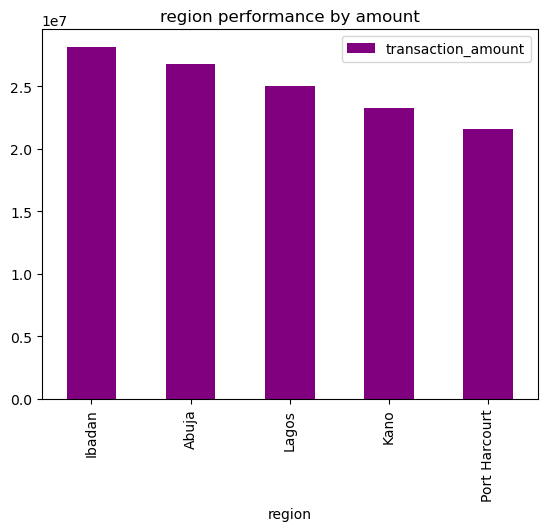

In [57]:
df_regionbyamount.sort_values('transaction_amount', ascending=False).plot(kind='bar', 
                       title= 'region performance by amount', 
                       color= 'purple',
                       x='region', y='transaction_amount')

#### The analysis shows that Ibadan contributes the highest share of total transaction volume, indicating a stronger concentration of customer activity and financial engagement in this region compared to others.

### 2. Which payment channel generate the highest transaction amount?

In [17]:
df_paymentchannelbyamount =df.groupby('payment_channel', as_index=False )['transaction_amount'].sum()
df_paymentchannelbyamount

,payment_channel,transaction_amount
0,bank_transfer,33179026.55
1,card,31344881.17
2,ussd,30395159.85
3,wallet,29841947.31


<Axes: title={'center': 'Payment Channel Performance By Amount'}, xlabel='payment_channel'>

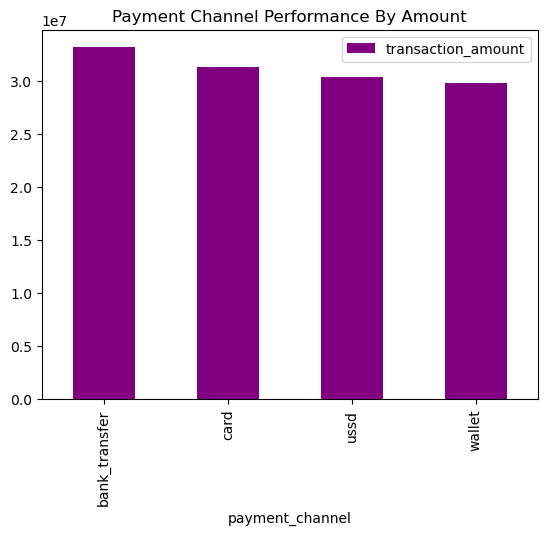

In [18]:
df_paymentchannelbyamount.plot(kind='bar', 
                               title= 'Payment Channel Performance By Amount', 
                               color= 'purple', 
                               x='payment_channel', y='transaction_amount')

#### The analysis shows that Bank Transfer recorded the highest total transaction value (33,179,026.55), indicating it is the most preferred and trusted payment channel among users. In contrast, Wallet transactions recorded the lowest total value (29,841,947.31), suggesting comparatively lower adoption or usage.


### 3. What device type generate the highest transaction amount?

In [19]:
df_devicetypebyamount=df.groupby('device_type', as_index=False)['transaction_amount'].sum()
df_devicetypebyamount

,device_type,transaction_amount
0,android,43565851.01
1,ios,36922610.07
2,web,44272553.80


<Axes: title={'center': 'transaction_amount by device_type'}, ylabel='transaction_amount'>

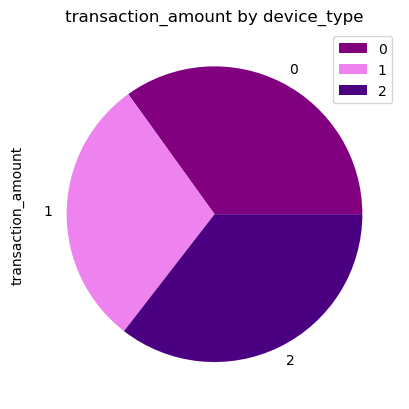

In [20]:
df_devicetypebyamount.plot(kind='pie', title= 'transaction_amount by device_type',
                           colors=['purple', 'violet', 'indigo'] ,
                           x='device_type', y='transaction_amount')

#### The analysis shows that Web and Android device types recorded the highest total transaction values, with 44,272,553.80 and 43,565,851.01 respectively, indicating that these platforms are the primary channels through which users conduct transactions.This suggests strong user engagement on both web and mobile (Android) platforms.

### 4. Which date has the highest transaction?

In [50]:
df_datebyamount= df.groupby('date', as_index=False)['transaction_amount'].sum()
df_datebyamount

,date,transaction_amount
0,2025-01-01,4635491.19
1,2025-01-02,5645229.72
2,2025-01-03,5420022.59
3,2025-01-04,5359162.01
4,2025-01-05,6858284.25
5,2025-01-06,6010509.97
6,2025-01-07,6469158.12
7,2025-01-08,7101651.13
8,2025-01-09,6199045.66
9,2025-01-10,5442294.78


<Axes: title={'center': 'Transaction Amount by Date'}, ylabel='date'>

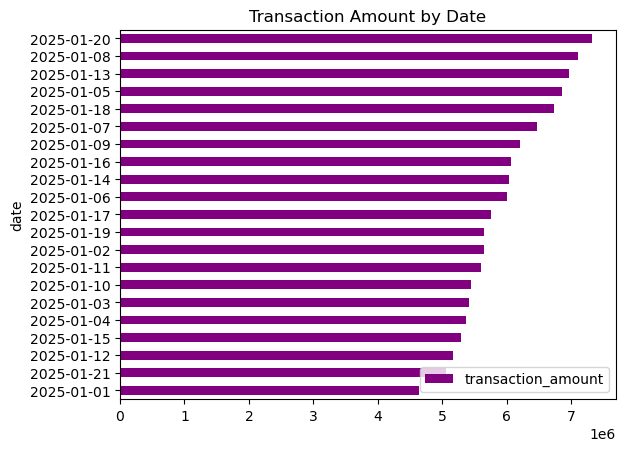

In [55]:
df_datebyamount.sort_values('transaction_amount', ascending=True).plot(kind='barh', 
                     title='Transaction Amount by Date', 
                     color= 'purple', 
                     x='date', y='transaction_amount')


#### The analysis shows that January 20th recorded the highest transaction value (7,327,817.54), while January 1st recorded the lowest (4,635,491.19).This indicates a noticeable variation in transaction activity over time, with peaks likely driven by increased user engagement or specific transaction triggers during certain periods.

### 5. What is the leading transaction status?

In [23]:
df_countoftransactionstatus =df.groupby('transaction_status', as_index=False)['transaction_amount'].count()
df_countoftransactionstatus

,transaction_status,transaction_amount
0,failed,41
1,pending,40
2,success,419


<Axes: title={'center': 'Transaction_status by Amount'}, ylabel='transaction_amount'>

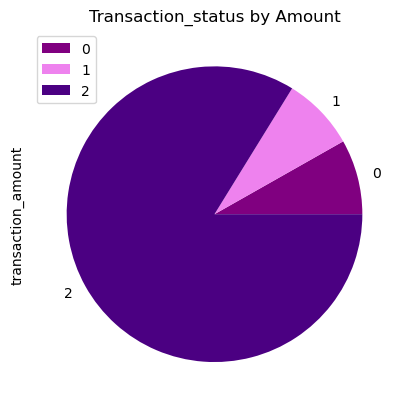

In [24]:
df_countoftransactionstatus.plot(kind='pie', title= 'Transaction_status by Amount', 
                                 colors=['purple', 'violet', 'indigo'],
                                 x='transaction_status', y='transaction_amount')

#### The analysis indicates that the majority of transactions are successful, with 419 successful transactions out of the total, compared to 41 failed and 40 pending transactions. This reflects a generally high transaction success rate and suggests that the platform is operating efficiently. However, the presence of failed and pending transactions highlights areas where system reliability and processing efficiency can still be improved.

### 6. what is the most used payment channel?

In [25]:
df_countofpaymentchannel = df.groupby('payment_channel', as_index=False)['transaction_amount'].count()
df_countofpaymentchannel

,payment_channel,transaction_amount
0,bank_transfer,132
1,card,121
2,ussd,127
3,wallet,120


<Axes: title={'center': 'transaction_amount by payment_channel'}, xlabel='payment_channel'>

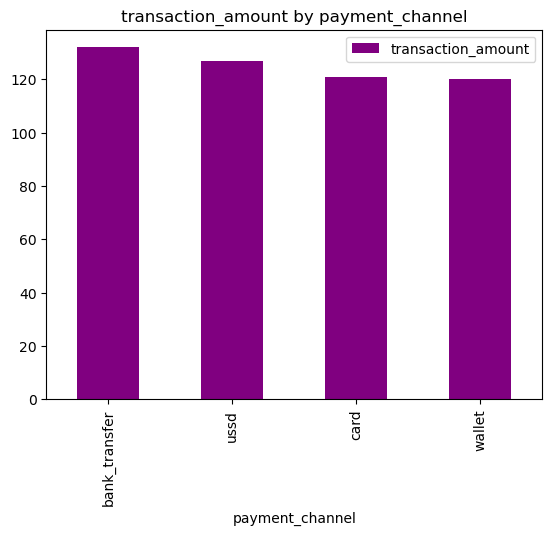

In [47]:
df_countofpaymentchannel.sort_values('transaction_amount', ascending=False).plot(kind='bar', 
                              title= 'transaction_amount by payment_channel', 
                              color='purple', 
                              x='payment_channel', y= 'transaction_amount')

#### The analysis shows that Bank Transfer is both the most frequently used payment method and the highest contributor to total transaction value, indicating strong user trust and its role as the primary transaction channel.

#### Additionally, while Card transactions generate a higher total transaction value than USSD, USSD is used more frequently, suggesting that Card is preferred for higher-value transactions, whereas USSD is used for more frequent, lower-value transactions. 

### 7. What is the most used transaction type?

In [27]:
df_countoftransactiontyplebyamount= df.groupby('transaction_type', as_index=False)['transaction_amount'].count()
df_countoftransactiontyplebyamount

,transaction_type,transaction_amount
0,airtime,130
1,bill,111
2,payment,127
3,transfer,132


<Axes: title={'center': 'Count_of_transaction by transaction_type'}, ylabel='transaction_type'>

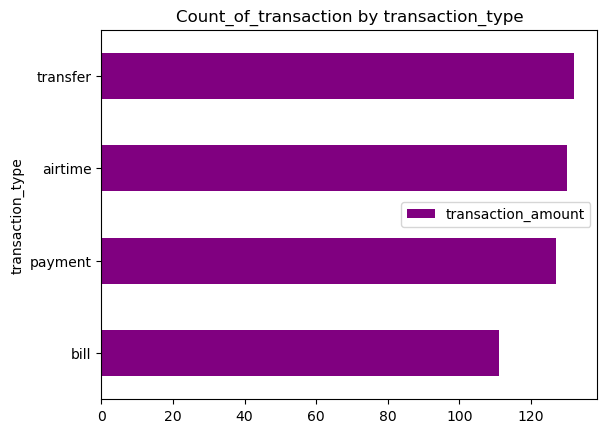

In [46]:
df_countoftransactiontyplebyamount.sort_values('transaction_amount', ascending=True).plot(kind='barh', title= 'Count_of_transaction by transaction_type',
                                        color='purple',
                                        x='transaction_type', y='transaction_amount')

#### The analysis shows that Transfer and Airtime transactions are the most frequently used transaction types, with 132 and 130 occurrences respectively, indicating strong user preference for these services in day-to-day financial activities.

### 8. What transaction type generates the highest transaction amount?

In [29]:
df_sumoftransactiontyplebyamount= df.groupby('transaction_type', as_index=False)['transaction_amount'].sum()
df_sumoftransactiontyplebyamount

,transaction_type,transaction_amount
0,airtime,31939714.91
1,bill,28153434.82
2,payment,33478738.46
3,transfer,31189126.69


<Axes: title={'center': 'transaction_amount by transaction_type'}, xlabel='transaction_type'>

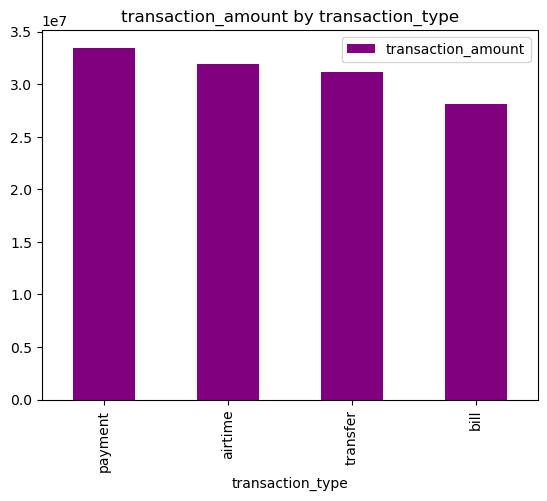

In [44]:
df_sumoftransactiontyplebyamount.sort_values('transaction_amount', ascending=False).plot(kind='bar', title= 'transaction_amount by transaction_type',
                                      color='purple',
                                      x='transaction_type', y='transaction_amount')

#### The analysis shows that Payment and Airtime transaction types generate the highest total transaction value, indicating strong user reliance on these services for everyday financial activities. In contrast, Bill transactions record the lowest transaction value, suggesting comparatively lower usage or engagement within this category.

### 9. Does the region with the highest transaction count generates the highest amount?

In [31]:
df_transactioncountandsumbyregion= df.groupby('region', as_index=False).agg(
    total_amount=('transaction_amount', 'sum'),
    transaction_count=('transaction_status', 'count'))
df_transactioncountandsumbyregion

,region,total_amount,transaction_count
0,Abuja,26747742.20,100
1,Ibadan,28138226.40,115
2,Kano,23236243.85,98
3,Lagos,25024642.79,97
4,Port Harcourt,21614159.64,90


array([<Axes: xlabel='region'>, <Axes: xlabel='region'>], dtype=object)

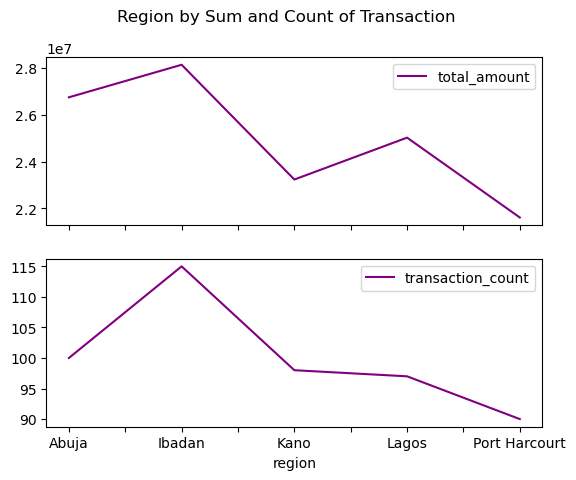

In [32]:
df_transactioncountandsumbyregion.plot(subplots=True, 
                                       color='purple',
                                       title='Region by Sum and Count of Transaction', 
                                       x='region', y=['total_amount', 'transaction_count'])

#### The analysis indicates that Ibadan recorded the highest transaction activity, with a total of 115 transactions and a corresponding transaction value of 28,138,226.40, making it the leading region in both volume and value. Abuja follows closely, with 100 transactions and a total value of 26,747,742.20, highlighting it as another key contributor to overall transaction performance.

In [33]:
FraudFlag = df.groupby('region', as_index=False)['fraud_flag'].sum()
FraudFlag

,region,fraud_flag
0,Abuja,7
1,Ibadan,5
2,Kano,7
3,Lagos,9
4,Port Harcourt,7


<Axes: title={'center': 'Region By Fraud Flag'}, xlabel='region'>

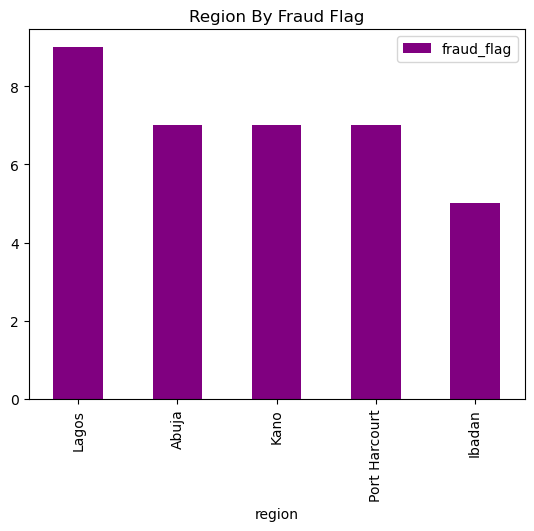

In [41]:
FraudFlag.sort_values('fraud_flag', ascending=False).plot(kind='bar', title='Region By Fraud Flag', color='purple', x='region', y='fraud_flag')

#### Out of a total of 500 transactions, 35 were flagged as fraudulent, indicating a measurable level of risk within the transaction system.Lagos recorded the highest number of fraud-flagged transactions (9), suggesting it may be a higher-risk region, while Ibadan recorded the lowest (5), indicating comparatively lower fraud activity.

### 10. what is the total sum of transaction amount?

In [35]:
df['transaction_amount'].sum()

124761014.88

### 11. What is the Maximum Transaction amount?

In [36]:
df['transaction_amount'].max()

498629.14

### 12. What is the Minimum Transaction amount?

In [37]:
df['transaction_amount'].min()

1796.21

### 13. what is the total number of user?

In [38]:
df['user_id'].count()

500

### 14. How many Fraud flag transaction is recorded?

In [39]:
df['fraud_flag'].sum()

35

## RECOMMENDATION

##### 1. Prioritize top region by increasing targeted marketing campaigns, partnerships, and customer retention strategies to further maximize revenue from this high-performing area.

##### 2. Given the dominance of Bank Transfer, the business should leverage this channel for high-value transactions while strategically promoting Wallet usage through targeted campaigns and product improvements to achieve a more balanced and diversified payment ecosystem.

##### 3. Given the strong performance of Ibadan and Abuja, the business should consider deepening market penetration in these regions while leveraging their success patterns to optimize performance in underperforming regions.

##### 4. Given the distinct usage patterns, the business should position Card as the preferred channel for high-value transactions and USSD as a convenient option for frequent, low-value transactions, while maintaining Bank Transfer as the core transaction backbone.

##### 5. The company should maintain its strong transaction success rate by continuously monitoring system performance and ensuring platform stability. Additionally, efforts should be made to reduce failed and pending transactions by identifying root causes such as network issues, processing delays, or user errors, and implementing solutions like improved error handling, faster processing systems, and clearer user guidance.

##### 6. Continue to optimize and enhance the performance of both Web and Android platforms, ensuring a seamless, fast, and secure user experience to maintain high transaction volumes.Additionally, insights from these platforms can be used to improve lower-performing device types, ensuring a consistent and efficient experience across all channels.

##### 7. A region-specific fraud management strategy should be implemented, focusing on high-risk areas like Lagos while maintaining strong preventive controls across all regions to ensure platform-wide security and user trust.